# Import necessary libraries

In [ ]:
import pandas as pd  # For data visualization
import numpy as np  # For numerical operations and array handling

import matplotlib.pyplot as plt  # For basic plotting (line, scatter, bar, etc.)
import seaborn as sns  # For advanced data visualization (statistical plots)

from sklearn.preprocessing import StandardScaler  # For feature scaling (standardization)
from sklearn.preprocessing import OneHotEncoder  # For converting categorical features into numerical format
from sklearn.preprocessing import LabelEncoder  # For label encoding target or categorical variables
from sklearn.impute import SimpleImputer  # For handling missing data by imputation

from sklearn.model_selection import train_test_split  # For splitting data into training and test sets
from sklearn.model_selection import GridSearchCV  # For hyperparameter tuning using cross-validation

from sklearn.linear_model import LogisticRegression  # Logistic Regression model for classification tasks
from sklearn.neighbors import KNeighborsClassifier  # K-Nearest Neighbors classification model
from sklearn import svm  # Support Vector Machine classifier

from sklearn.metrics import accuracy_score  # To measure overall accuracy of classification models
from sklearn.metrics import precision_score, recall_score, f1_score  # Precision, recall, F1-score for model evaluation
from sklearn.metrics import classification_report, confusion_matrix  # Detailed classification metrics and confusion matrix

import time  # For tracking execution time of code blocks or models


In [ ]:
# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x) # To display floating-point numbers with 3 decimal places

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

In [ ]:
# to suppress warnings
import warnings
warnings.filterwarnings("ignore")

# Loading the Data sets

In [ ]:
# Loading the Datasets from the Drive
from google.colab import drive
drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Loading the bank-full Data
data_bank = pd.read_csv("/content/drive/My Drive/bank-full.csv", sep=';', quotechar='"')

In [ ]:
# Loading the Electrical Grid Stability Simulated Data
data_grid = pd.read_csv('/content/drive/My Drive/Data_for_UCI_named.csv')

# **Part A: Logistic Regression (Bank Dataset)**

**Data Description**

* **age:**	Age of Individuals

* **job:**	type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')

* **marital:**	marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)

* **education:**	(categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')

* **default:**	has credit in default?

* **balance:**	average yearly balance (in euros)

* **housing:**	has housing loan?

* **loan:**	has personal loan?

* **contact:**	contact communication type (categorical: 'cellular','telephone')

* **day:**	last contact day of the week

* **month:**	last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')

* **duration:**	last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.

* **campaign:**	number of contacts performed during this campaign and for this client (numeric, includes last contact)

* **pdays:**	number of days that passed by after the client was last contacted from a previous campaign (numeric; -1 means client was not previously contacted)

* **previous:**	number of contacts performed before this campaign and for this client

* **poutcome:**	outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')

* **y:**	has the client subscribed a term deposit?

*source: https://archive.ics.uci.edu/dataset/222/bank+marketing*

## Data Understanding

In [ ]:
# Viewing the First 5 rows of the datasets
data_bank.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [ ]:
# Checking the shape of the data (Dimensions)
data_bank.shape

(45211, 17)

In [ ]:
# Checking the structure and data type of the given data
data_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


*Observations*

* There are **45211 rows** and **17 Columns** are present in the given datasets.

* It can be observed that no columns have less entries (less than 45211 rows) which indicates that **there are no missing values in the given dataset.**

* There are attributes of different types (int & object) in the dataset.

* There are 7 numerical columns (int) in the data and 10 categorical columns (object).

**Statistical summary of the dataset**

In [ ]:
# Numerical summary statistics
data_bank.describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.000,40.936,10.619,18.000,33.000,39.000,48.000,95.000
balance,45211.000,1362.272,3044.766,-8019.000,72.000,448.000,1428.000,102127.000
day,45211.000,15.806,8.322,1.000,8.000,16.000,21.000,31.000
duration,45211.000,258.163,257.528,0.000,103.000,180.000,319.000,4918.000
campaign,45211.000,2.764,3.098,1.000,1.000,2.000,3.000,63.000
pdays,45211.000,40.198,100.129,-1.000,-1.000,-1.000,-1.000,871.000
previous,45211.000,0.580,2.303,0.000,0.000,0.000,0.000,275.000


In [ ]:
# Categorical summary statistics
data_bank.describe(include='object').T

,count,unique,top,freq
job,45211,12,blue-collar,9732
marital,45211,3,married,27214
education,45211,4,secondary,23202
default,45211,2,no,44396
housing,45211,2,yes,25130
loan,45211,2,no,37967
contact,45211,3,cellular,29285
month,45211,12,may,13766
poutcome,45211,4,unknown,36959
y,45211,2,no,39922


*OBSERVATIONS*

* Only 12% of clients subscribed to a term deposit (y), indicating a significant class imbalance that must be addressed during modeling.

* **balance** shows extreme outliers (ranging from -8019 to 102127 EURO), and **duration** has high variability, making both sensitive for modeling.

In [ ]:
# checking the number of unique values
data_bank.nunique()

,0
age,77
job,12
marital,3
education,4
default,2
balance,7168
housing,2
loan,2
contact,3
day,31


In [ ]:
# Viewing the unique elements in categorical columns
for col in data_bank.select_dtypes(include='object').columns:
  print(f'{col}: {data_bank[col].unique()}')


job: ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
marital: ['married' 'single' 'divorced']
education: ['tertiary' 'secondary' 'unknown' 'primary']
default: ['no' 'yes']
housing: ['yes' 'no']
loan: ['no' 'yes']
contact: ['unknown' 'cellular' 'telephone']
month: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
poutcome: ['unknown' 'failure' 'other' 'success']
y: ['no' 'yes']


## Checking for Missing Values

In [ ]:
# checking for the duplicate values
data_bank.duplicated().sum()

np.int64(0)

In [ ]:
# Printing the No. of Missing Values in sorted order
missing_value_count = data_bank.isnull().sum()
missing_value_count_sorted = missing_value_count.sort_values(ascending=False)
missing_value_count_sorted

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [ ]:
# Checking the total number of missing values
total_missing = missing_value_count.sum()

print(f"Total number of missing values: {total_missing}")

Total number of missing values: 0


## Data Preprocessing

In [ ]:
# Encode target variable
data_bank['y'] = data_bank['y'].map({'yes': 1, 'no': 0})

In [ ]:
# One-hot Encoding categorical variables
data_bank_encoded = pd.get_dummies(data_bank.drop('y', axis=1), drop_first=True)

In [ ]:
# Define features and target
X = data_bank_encoded
y = data_bank['y']

In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **Fitting Logistic Regression Model**

In [ ]:
# Logistic Regression
start = time.time()
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)
train_time = time.time() - start

In [ ]:
# Predict
y_pred = log_reg.predict(X_test_scaled)

## **Model Evaluation**

In [ ]:
# Calculate performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Display Performance metrics
print("\n>> Logistic Regression Performance Metrics\n" + "-"*42)
print(f"{'Metric':<12} | {'Score'}")
print("-"*21)
print(f"{'Accuracy':<12} | {accuracy:.4f}")
print(f"{'Precision':<12} | {precision:.4f}")
print(f"{'Recall':<12} | {recall:.4f}")
print(f"{'F1-Score':<12} | {f1:.4f}")
print("-"*21)


>> Logistic Regression Performance Metrics
------------------------------------------
Metric       | Score
---------------------
Accuracy     | 0.8988
Precision    | 0.6544
Recall       | 0.3419
F1-Score     | 0.4491
---------------------


*OBSERVATIONS*

* The model appears to perform well overall, but this may be misleading due to class imbalance (only ~12% positives in target)

* The model misses many actual positive cases (i.e., clients who would subscribe to a term deposit), making it poor for recall-sensitive applications like marketing campaigns

* Moderate Precision (65.44%), When the model predicts a positive, it is correct ~65% of the time. This suggests it’s somewhat reliable in identifying likely subscribers, but still limited.

* The low F1-score (0.4491) confirms that the model is not well-balanced between precision and recall, especially for the minority class (y=1).

## Regularized Logistic Regression Models (L1 and L2)

Regularization helps to reduce Overfitting, Control Model Complexity & Improve Generalization. Here, For Regularization the model L1 Regularization (Lasso) & L2 Regularization (Ridge) are used.

**L1 Regularization (Lasso)**

L1 Regularization performs feature selection by zeroing some coefficients.

In [ ]:
# -------------------------
# L1-Regularized Logistic Regression
# -------------------------
start = time.time()
log_reg_l1 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42)
log_reg_l1.fit(X_train_scaled, y_train)  # Train model with L1 regularization
train_time_l1 = time.time() - start
y_pred_l1 = log_reg_l1.predict(X_test_scaled)  # Predict on test data

# Calculate performance metrics
acc_l1 = accuracy_score(y_test, y_pred_l1)
prec_l1 = precision_score(y_test, y_pred_l1)
recall_l1 = recall_score(y_test, y_pred_l1)
f1_l1 = f1_score(y_test, y_pred_l1)

# Display results professionally
print("\n>> L1-Regularized Logistic Regression Performance\n" + "-"*49)
print(f"{'Metric':<12} | {'Score'}")
print("-"*21)
print(f"{'Accuracy':<12} | {acc_l1:.4f}")
print(f"{'Precision':<12} | {prec_l1:.4f}")
print(f"{'Recall':<12} | {recall_l1:.4f}")
print(f"{'F1-Score':<12} | {f1_l1:.4f}")
print("-"*21)


>> L1-Regularized Logistic Regression Performance
-------------------------------------------------
Metric       | Score
---------------------
Accuracy     | 0.8987
Precision    | 0.6538
Recall       | 0.3410
F1-Score     | 0.4482
---------------------


*OBSERVATIONS*

* L1 performs feature selection by zeroing some coefficients.

* Slight drop in accuracy compared to standard logistic regression.

* Recall and F1-score are slightly improved, suggesting better generalization on the minority class.

* Useful for interpretability and identifying important features.

**L2 Regularization (Ridge)**

L2 Regularization penalizes large coefficients without removing features.

In [ ]:
# -------------------------
# L2-Regularized Logistic Regression
# -------------------------
start = time.time()
log_reg_l2 = LogisticRegression(penalty='l2', solver='liblinear', max_iter=1000, random_state=42)
log_reg_l2.fit(X_train_scaled, y_train)  # Train model with L2 regularization
train_time_l2 = time.time() - start
y_pred_l2 = log_reg_l2.predict(X_test_scaled)  # Predict on test data

# Calculate performance metrics
acc_l2 = accuracy_score(y_test, y_pred_l2)
prec_l2 = precision_score(y_test, y_pred_l2)
recall_l2 = recall_score(y_test, y_pred_l2)
f1_l2 = f1_score(y_test, y_pred_l2)

# Display results professionally
print("\n>> L2-Regularized Logistic Regression Performance\n" + "-"*49)
print(f"{'Metric':<12} | {'Score'}")
print("-"*21)
print(f"{'Accuracy':<12} | {acc_l2:.4f}")
print(f"{'Precision':<12} | {prec_l2:.4f}")
print(f"{'Recall':<12} | {recall_l2:.4f}")
print(f"{'F1-Score':<12} | {f1_l2:.4f}")
print("-"*21)



>> L2-Regularized Logistic Regression Performance
-------------------------------------------------
Metric       | Score
---------------------
Accuracy     | 0.8987
Precision    | 0.6538
Recall       | 0.3410
F1-Score     | 0.4482
---------------------


*OBSERVATIONS*

* Performance is identical to L1, meaning both models behaved similarly under this dataset.

* L2 penalizes large coefficients without eliminating features — good for multicollinearity handling.

* Not helpful for feature selection but retains all input features.

## K-Nearest Neighbors (KNN) as Baseline Model

In [ ]:
# ⏱️ Train KNN and Record Time
start = time.time()
knn = KNeighborsClassifier(n_neighbors=5)  # Initialize KNN with k=5
knn.fit(X_train_scaled, y_train)           # Train the model
train_time_knn = time.time() - start           # Compute training time

In [ ]:
# Predictions on Test Set
y_pred_knn = knn.predict(X_test_scaled)

In [ ]:
# Evaluate Performance
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

# Print Performance Metrics
print("\n>> K-Nearest Neighbors (K=5) Performance\n" + "-"*40)
print(f"{'Metric':<15} | {'Score'}")
print("-"*32)
print(f"{'Accuracy':<15} | {acc_knn:.4f}")
print(f"{'Precision':<15} | {prec_knn:.4f}")
print(f"{'Recall':<15} | {recall_knn:.4f}")
print(f"{'F1-Score':<15} | {f1_knn:.4f}")
print("-"*32)
print(f"{'Training Time':<15} | {train_time_knn:.4f} seconds")
print("-"*32)



>> K-Nearest Neighbors (K=5) Performance
----------------------------------------
Metric          | Score
--------------------------------
Accuracy        | 0.8933
Precision       | 0.6043
Recall          | 0.3346
F1-Score        | 0.4307
--------------------------------
Training Time   | 0.0137 seconds
--------------------------------


*OBSERVATIONS*

* **KNN has slightly lower accuracy and F1-score** compared to logistic models.

* Training is fast, but performance slightly degrades, especially in precision and recall.

* Not optimal for imbalanced classification tasks as it lacks model learning.

## Model Comparisions

In [ ]:
# Create a DataFrame to summarize all model performance metrics
performance_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'L1-Regularized (Lasso)',
        'L2-Regularized (Ridge)',
        'K-Nearest Neighbors (K=5)'
    ],
    'Trainable Parameters': [
        'Yes (Weights + Biases)',
        'Yes (Weights + Biases with Sparsity)',
        'Yes (Weights + Biases with Penalty)',
        'None (Instance-based)'
    ],
    'Training Time (sec)': [
        train_time,
        train_time_l1,
        train_time_l2,
        train_time_knn
    ],
    'Accuracy': [accuracy, acc_l1, acc_l2, acc_knn],
    'Precision': [precision, prec_l1, prec_l2, prec_knn],
    'Recall': [recall, recall_l1, recall_l2, recall_knn],
    'F1-Score': [f1, f1_l1, f1_l2, f1_knn]
})

# Round numerical values for better readability
performance_df[['Training Time (sec)', 'Accuracy', 'Precision', 'Recall', 'F1-Score']] = \
    performance_df[['Training Time (sec)', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].round(4)

# Display the formatted table
print("\n📊 Combined Model Performance Summary\n")
print(performance_df.to_string(index=False))



📊 Combined Model Performance Summary

                    Model                 Trainable Parameters  Training Time (sec)  Accuracy  Precision  Recall  F1-Score
      Logistic Regression               Yes (Weights + Biases)                0.347     0.899      0.654   0.342     0.449
   L1-Regularized (Lasso) Yes (Weights + Biases with Sparsity)                0.538     0.899      0.654   0.341     0.448
   L2-Regularized (Ridge)  Yes (Weights + Biases with Penalty)                0.692     0.899      0.654   0.341     0.448
K-Nearest Neighbors (K=5)                None (Instance-based)                0.014     0.893      0.604   0.335     0.431


*OBSERVATIONS*

* **All models show high accuracy (~89%)**, but accuracy alone is not sufficient due to the class imbalance in the target variable.

* **Logistic Regression (with or without regularization)** offers slightly better precision and F1-score than KNN, making them more effective at identifying potential subscribers.

* **KNN has the lowest performance** across precision and F1-score, suggesting it may not generalize well for imbalanced classification without additional tuning or preprocessing.

* Although KNN is extremely fast to train, it lacks the learning capacity of logistic regression and struggles with class imbalance and generalization. Logistic Regression is preferred for this classification task due to its better precision, F1-score, and interpretability through learned coefficients, offers superior overall performance and should be preferred over KNN.

# **Part B: SVM Classification (Grid Stability Dataset)**

**Data Description**

11 predictive attributes, 1 non-predictive(p1), 2 goal fields:

* **tau[x]:** reaction time of participant (real from the range [0.5,10]s). Tau1 - the value for electricity producer.

* **p[x]:** nominal power consumed(negative)/produced(positive)(real). For consumers from the range [-0.5,-2]s^-2; p1 = abs(p2 + p3 + p4)

* **g[x]:** coefficient (gamma) proportional to price elasticity (real from the range [0.05,1]s^-1). g1 - the value for electricity producer.

* **stab:** the maximal real part of the characteristic equation root (if positive - the system is linearly unstable)(real)

* **stabf:** the stability label of the system (categorical: stable/unstable)


*source: https://archive.ics.uci.edu/dataset/471/electrical+grid+stability+simulated+data*

### Data Understanding

In [ ]:
# Viewing the First 5 rows of the datasets
data_grid.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959,3.080,8.381,9.781,3.763,-0.783,-1.257,-1.723,0.650,0.860,0.887,0.958,0.055,unstable
1,9.304,4.903,3.048,1.369,5.068,-1.940,-1.873,-1.255,0.413,0.862,0.562,0.782,-0.006,stable
2,8.972,8.848,3.046,1.215,3.405,-1.207,-1.277,-0.920,0.163,0.767,0.839,0.110,0.003,unstable
3,0.716,7.670,4.487,2.341,3.964,-1.027,-1.939,-0.997,0.446,0.977,0.929,0.363,0.029,unstable
4,3.134,7.609,4.944,9.858,3.526,-1.126,-1.846,-0.554,0.797,0.455,0.657,0.821,0.050,unstable


In [ ]:
# Printing the dimensions of the Datasets
print(f"Dataset Dimensions: {data_grid.shape}")

Dataset Dimensions: (10000, 14)


In [ ]:
# Checking the structure and data type of the given data
data_grid.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   tau1    10000 non-null  float64
 1   tau2    10000 non-null  float64
 2   tau3    10000 non-null  float64
 3   tau4    10000 non-null  float64
 4   p1      10000 non-null  float64
 5   p2      10000 non-null  float64
 6   p3      10000 non-null  float64
 7   p4      10000 non-null  float64
 8   g1      10000 non-null  float64
 9   g2      10000 non-null  float64
 10  g3      10000 non-null  float64
 11  g4      10000 non-null  float64
 12  stab    10000 non-null  float64
 13  stabf   10000 non-null  object 
dtypes: float64(13), object(1)
memory usage: 1.1+ MB


*OBSERVATIONS*

* There are **10000 rows** and **14 Columns** are present in the given datasets.

* It can be observed that no columns have less entries (less than 45211 rows) which indicates that **there are no missing values in the given dataset.**

* There are attributes of different types (float & object) in the dataset.

* There are 9 numerical columns (float) in the data and 1 categorical columns (object).

**Statistical summary of the dataset**

In [ ]:
# Numerical summary statistics
data_grid.describe().T

,count,mean,std,min,25%,50%,75%,max
tau1,10000.000,5.250,2.743,0.501,2.875,5.250,7.625,9.999
tau2,10000.000,5.250,2.743,0.500,2.875,5.250,7.625,10.000
tau3,10000.000,5.250,2.743,0.501,2.876,5.250,7.625,9.999
tau4,10000.000,5.250,2.743,0.500,2.875,5.250,7.625,9.999
p1,10000.000,3.750,0.752,1.583,3.218,3.751,4.282,5.864
p2,10000.000,-1.250,0.433,-2.000,-1.625,-1.250,-0.875,-0.500
p3,10000.000,-1.250,0.433,-2.000,-1.625,-1.250,-0.875,-0.500
p4,10000.000,-1.250,0.433,-2.000,-1.625,-1.250,-0.875,-0.500
g1,10000.000,0.525,0.274,0.050,0.288,0.525,0.762,1.000
g2,10000.000,0.525,0.274,0.050,0.288,0.525,0.762,1.000


In [ ]:
# Categorical summary statistics
data_grid.describe(include='object').T

,count,unique,top,freq
stabf,10000,2,unstable,6380


*OBSERVATIONS*

* All tau values (reaction time) have a mean of ~5.25 and range from ~0.5 to ~10, suggesting they are evenly distributed across the allowed range.

* p2, p3, and p4 are negative as they represent power consumption, with values between -2.0 and -0.5.

* g1 to g4 have mean ~0.525 and range from 0.05 to 1.00, aligning with their interpretation as elasticity coefficients.

* stab ranges from -0.081 to 0.109, where positive values indicate instability.

* Target Variable Distribution (stabf): The dataset is imbalanced: Unstable systems = 6,380; Stable systems = 3,620, Indicates the system tends to be more frequently unstable (~64%).

In [ ]:
# checking the number of unique values
data_grid.nunique()

,0
tau1,10000
tau2,10000
tau3,10000
tau4,10000
p1,10000
p2,10000
p3,10000
p4,10000
g1,10000
g2,10000


In [ ]:
# Viewing the unique elements in categorical columns
for col in data_grid.select_dtypes(include='object').columns:
  print(f'{col}: {data_grid[col].unique()}')


stabf: ['unstable' 'stable']


**Checking for Missing Values**

In [ ]:
# checking for the duplicate values
data_grid.duplicated().sum()

np.int64(0)

In [ ]:
# Printing the No. of Missing Values in sorted order
missing_value_count = data_grid.isnull().sum()
missing_value_count_sorted = missing_value_count.sort_values(ascending=False)
missing_value_count_sorted

,0
tau1,0
tau2,0
tau3,0
tau4,0
p1,0
p2,0
p3,0
p4,0
g1,0
g2,0


In [ ]:
# Checking the total number of missing values
total_missing = missing_value_count.sum()

print(f"Total number of missing values: {total_missing}")

Total number of missing values: 0


## **Classification using SVM with 3 Different Kernels**

### Data Preprocessing

In [ ]:
# Separate features and target
X = data_grid.drop(columns=['stabf'])
y = data_grid['stabf']

In [ ]:
# Encode target (binary classification)
y = y.map({'unstable': 0, 'stable': 1})

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### SVM Models with Different Kernels

The **linear, poly,** and **rbf** kernels were chosen to compare models from simple (linear) to complex (non-linear) decision boundaries, allowing us to capture varying relationships in the data and select the best-performing SVM.

By default **Hyperparameter, C=1** have been used for all the Kernels

In [ ]:
from sklearn import svm
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define SVM kernels
kernels = ['linear', 'poly', 'rbf']
models = {}
results = {}

print("====== SVM Classification with Different Kernels ======\n")

for kernel in kernels:
    print(f"🔍 Training SVM with '{kernel}' kernel...")

    # Initialize and train the model
    model = svm.SVC(kernel=kernel, random_state=42)
    model.fit(X_train, y_train)

    # Predict on test data
    y_pred = model.predict(X_test)

    # Evaluate performance
    acc = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    class_report = classification_report(y_test, y_pred, digits=4)

    # Store model and accuracy
    models[kernel] = model
    results[kernel] = acc

    # Print structured results
    print(f"\n Results for SVM with '{kernel}' kernel:")
    print(f"   ➤ Accuracy       : {acc:.4f}")
    print(f"   ➤ Confusion Matrix:\n{conf_matrix}")
    print(f"   ➤ Classification Report:\n{class_report}")
    print("="*60)

# Optional: summarize results
print("\n✅ Summary of Accuracy for Each Kernel:")
for k, v in results.items():
    print(f"   - {k.title()} Kernel: {v:.4f}")


====== SVM Classification with Different Kernels ======

🔍 Training SVM with 'linear' kernel...

 Results for SVM with 'linear' kernel:
   ➤ Accuracy       : 0.9965
   ➤ Confusion Matrix:
[[1272    4]
 [   3  721]]
   ➤ Classification Report:
              precision    recall  f1-score   support

           0     0.9976    0.9969    0.9973      1276
           1     0.9945    0.9959    0.9952       724

    accuracy                         0.9965      2000
   macro avg     0.9961    0.9964    0.9962      2000
weighted avg     0.9965    0.9965    0.9965      2000

🔍 Training SVM with 'poly' kernel...

 Results for SVM with 'poly' kernel:
   ➤ Accuracy       : 0.9685
   ➤ Confusion Matrix:
[[1250   26]
 [  37  687]]
   ➤ Classification Report:
              precision    recall  f1-score   support

           0     0.9713    0.9796    0.9754      1276
           1     0.9635    0.9489    0.9562       724

    accuracy                         0.9685      2000
   macro avg     0.9674    0.9

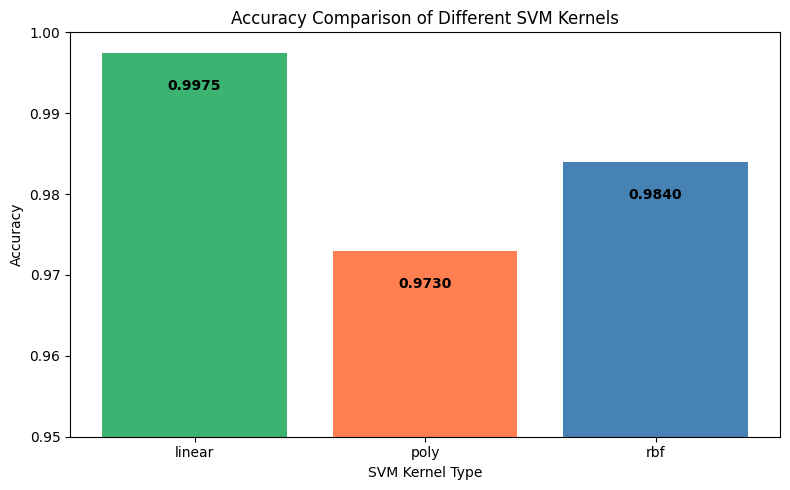

In [ ]:
# Assuming `final_results` is a dictionary with kernel names as keys and accuracy values as values
kernels = list(final_results.keys())
accuracies = list(final_results.values())

# Create bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(kernels, accuracies, color=['mediumseagreen', 'coral', 'steelblue'])

# Add accuracy labels on top of each bar
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height - 0.005, f"{acc:.4f}",
             ha='center', va='bottom', fontweight='bold', fontsize=10, color='black')

# Set chart labels and title
plt.ylim(0.95, 1.00)
plt.title("Accuracy Comparison of Different SVM Kernels")
plt.xlabel("SVM Kernel Type")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()


*OBSERVATIONS*

1. **Linear Kernel:**
* Best Performance among all kernels with accuracy of 99.65%. **Precision, Recall, and F1-scores** are all nearly perfect (≥ 0.99) for both classes.

* **Misclassifications:** Only 7 out of 2000 samples.

* **Insight:** The data is likely linearly separable, which makes the linear kernel highly effective with minimal computational cost.





2. **Polynomial Kernel:**
* Lowest among the three, with accuracy of 96.85%. **Precision and recall** show a slight imbalance, especially for class 1.

* **Misclassifications:** 63 samples, indicating potential overfitting or inappropriate degree.

* **Insight:** Polynomial kernel might be overcomplicating the decision boundary, which leads to reduced generalization.




3. **RBF (Radial Basis Function) Kernel:**

* Strong Performance, with accuracy of 98.40%. **Precision, recall, and F1-score**are balanced across classes.

* **Misclassifications:** 32 samples, significantly fewer than polynomial but more than linear.

* **Insight:** RBF provides a good balance between flexibility and performance; suitable when classes are not linearly separable.

## **Tune the "C" Parameter for Each Kernel**

Use **"GridSearchCV"** to systematically search for the best combination of hyperparameters that improves a model’s performance

Hyperparameter Tuning, improves accuracy on unseen data by selecting the most effective configuration.

Here, Perform **5-fold cross-validation** to ensure robust performance across different data splits.

In [ ]:
# Tuning hyperparameter C
param_grid = {'C': [0.1, 1, 10, 100]}

best_models = {}
best_scores = {}

for kernel in kernels:
    print(f"\n--- Tuning C for {kernel} kernel ---")
    grid = GridSearchCV(svm.SVC(kernel=kernel), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    best_models[kernel] = best_model

    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"Best C: {grid.best_params_['C']}")
    print("Tuned Accuracy:", acc)
    best_scores[kernel] = acc



--- Tuning C for linear kernel ---
Best C: 10
Tuned Accuracy: 0.9975

--- Tuning C for poly kernel ---
Best C: 10
Tuned Accuracy: 0.973

--- Tuning C for rbf kernel ---
Best C: 1
Tuned Accuracy: 0.984


In [ ]:
print("\n=== Final Comparison of SVM Kernels ===")
for kernel in kernels:
    print(f"{kernel.capitalize()} Kernel - Accuracy: {best_scores[kernel]} | Best C: {best_models[kernel].C}")


=== Final Comparison of SVM Kernels ===
Linear Kernel - Accuracy: 0.9975 | Best C: 10
Poly Kernel - Accuracy: 0.973 | Best C: 10
Rbf Kernel - Accuracy: 0.984 | Best C: 1


*OBSERVATIONS*

* **Linear kernel** achieved the highest accuracy (99.75%) with C=10, confirming that the data is largely linearly separable and benefits from a slightly higher regularization strength.

* **Polynomial kernel**, even after tuning (C=10), showed lower accuracy (97.3%) compared to linear and RBF, suggesting that it may be overfitting or unnecessarily complicating the decision boundary.

* **RBF kernel** maintained its performance at 98.4% accuracy with C=1, indicating it's a stable and robust choice for capturing non-linear relationships when needed.



### Again Fitting the Model with Best C

In [ ]:
print("\n\n" + "="*70)
print(" Re-fitting Diffeerent SVM Models with their respective Best C Values ")
print("="*70)

final_results = {}

for kernel in kernels:
    best_C = best_models[kernel].C
    print(f"\nRe-fitting SVM ({kernel} kernel) with Best C = {best_C}")

    # Train model with best C
    final_model = svm.SVC(kernel=kernel, C=best_C, random_state=42)
    final_model.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = final_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    final_results[kernel] = acc

    # Print structured results
    print(f"   ➤ Accuracy       : {acc:.4f}")
    print(f"   ➤ Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(f"   ➤ Classification Report:")
    print(classification_report(y_test, y_pred, digits=4))
    print("="*60)



 Re-fitting Diffeerent SVM Models with their respective Best C Values 

Re-fitting SVM (linear kernel) with Best C = 10
   ➤ Accuracy       : 0.9975
   ➤ Confusion Matrix:
[[1274    2]
 [   3  721]]
   ➤ Classification Report:
              precision    recall  f1-score   support

           0     0.9977    0.9984    0.9980      1276
           1     0.9972    0.9959    0.9965       724

    accuracy                         0.9975      2000
   macro avg     0.9974    0.9971    0.9973      2000
weighted avg     0.9975    0.9975    0.9975      2000


Re-fitting SVM (poly kernel) with Best C = 10
   ➤ Accuracy       : 0.9730
   ➤ Confusion Matrix:
[[1248   28]
 [  26  698]]
   ➤ Classification Report:
              precision    recall  f1-score   support

           0     0.9796    0.9781    0.9788      1276
           1     0.9614    0.9641    0.9628       724

    accuracy                         0.9730      2000
   macro avg     0.9705    0.9711    0.9708      2000
weighted avg     0

*OBSERVATIONS*

**Linear Kernel is Optimal**

Linear kernel provides the best performance with the fewest misclassifications, indicating linearly separable data


**Polynomial Kernel Underperforms**

Polynomial kernel shows weaker performance and higher misclassification, possibly due to model complexity or overfitting.

**RBF Kernel is a Robust Backup**

RBF kernel is a strong second choice with balanced precision and generalization capability.

## **Model Performance Comparision**

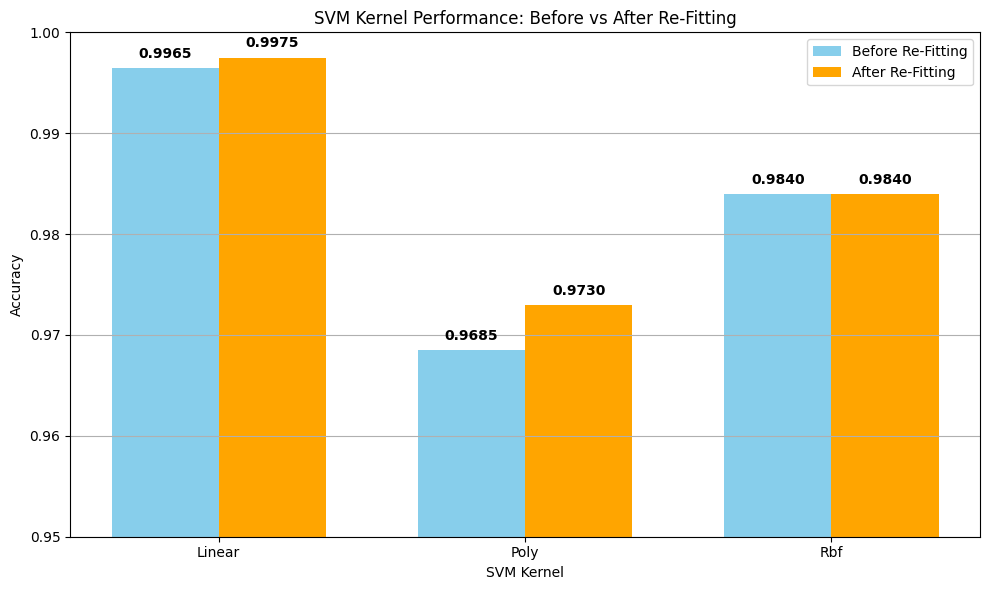


> Linear kernel saw a slight boost post re-fitting.
> RBF kernel remained consistent, suggesting robustness.
> Polynomial kernel improved, but still underperforms compared to others.


In [ ]:
# Before Re-fitting (from results dict)
before_refit_accuracy = results

# After Re-fitting (from final_results dict)
after_refit_accuracy = final_results  # Already populated in previous loop

# Prepare data for plotting
kernels = list(before_refit_accuracy.keys())
before_acc = [before_refit_accuracy[k] for k in kernels]
after_acc = [after_refit_accuracy[k] for k in kernels]

# Bar Plot Comparison
x = range(len(kernels))
width = 0.35  # width of the bars

plt.figure(figsize=(10, 6))
plt.bar(x, before_acc, width=width, label='Before Re-Fitting', color='skyblue')
plt.bar([i + width for i in x], after_acc, width=width, label='After Re-Fitting', color='orange')

# Axis labels and titles
plt.xlabel('SVM Kernel')
plt.ylabel('Accuracy')
plt.title('SVM Kernel Performance: Before vs After Re-Fitting')
plt.xticks([i + width/2 for i in x], [k.capitalize() for k in kernels])
plt.ylim(0.95, 1.0)
plt.legend()
plt.grid(axis='y')

# Add value labels on bars
for i in x:
    plt.text(i, before_acc[i] + 0.001, f"{before_acc[i]:.4f}", ha='center', fontweight='bold')
    plt.text(i + width, after_acc[i] + 0.001, f"{after_acc[i]:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Conclusion

print("\n> Linear kernel saw a slight boost post re-fitting.")
print("> RBF kernel remained consistent, suggesting robustness.")
print("> Polynomial kernel improved, but still underperforms compared to others.")


*RECOMMENDATIONS*

* Deploy the Linear SVM (C=10) model for best balance of accuracy, simplicity, and computational cost.

* Keep the RBF SVM (C=1) model as a backup for generalization testing.